# Twitch Sponsorship Optimization Agent
## Component 5 -- Integration and Agent Wrapper

**Course:** MGMT 590-037 -- AI-Enhanced Optimization -- Daniels School of Business
**Pipeline position:** Data -> Prediction -> Optimization -> Explanation -> **Agent**

This notebook is the end-to-end integration of all prior components. It exposes
a single entry point (`run_agent`) that accepts either a natural language
description or a structured spec dict and returns an allocation plus a
plain-language explanation. An LLM parser (Claude API) translates natural
language into spec fields; a rules-based parser serves as fallback if no API
key is present.

The notebook also satisfies the 5.2 checklist requirements: non-convexity
verification with combined objective plot, solver robustness cell comparing
basin-hopping vs. dual annealing vs. single SLSQP, and a full benchmark test.

**Required packages:**
```
pip install pandas numpy scipy matplotlib anthropic
```

**API key:** Set `ANTHROPIC_API_KEY` in your environment or in `secrets.env`
at the repo root. Without a key the agent falls back to the rules-based parser.

**How to run:** Execute cells top-to-bottom from a clean kernel. All outputs
are self-contained.

---
## Setup -- Cell 1 (all imports, configuration, secrets)

In [1]:
# ============================== CELL 1: ALL IMPORTS ==============================
import os
import re
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from scipy.optimize import minimize, basinhopping, dual_annealing

try:
    import anthropic
    _ANTHROPIC_INSTALLED = True
except ImportError:
    _ANTHROPIC_INSTALLED = False

# ── Configuration ──────────────────────────────────────────────────────────────
%matplotlib inline
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
pd.set_option("display.width", 120)

# ── Load API key from secrets.env if present ───────────────────────────────────
def _load_secrets(path):
    if not Path(path).exists():
        return
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith("#") and "=" in line:
                k, v = line.split("=", 1)
                os.environ.setdefault(k.strip(), v.strip().strip('"').strip("'"))

for _p in ["../secrets.env", "secrets.env", ".env"]:
    _load_secrets(_p)

API_KEY          = os.environ.get("ANTHROPIC_API_KEY", "")
LLM_AVAILABLE    = _ANTHROPIC_INSTALLED and bool(API_KEY)
LLM_MODEL        = "claude-sonnet-4-20250514"

# ── Data resolver ──────────────────────────────────────────────────────────────
SPEC_CANDIDATES = [
    Path("../data/outputs"),
    Path("data/outputs"),
    Path("../outputs"),
    Path("outputs"),
    Path("/mnt/user-data/outputs"),
]

def resolve_dir(probe, candidates):
    for d in candidates:
        if (d / probe).exists():
            return d.resolve()
    searched = "\n".join(f"  - {d.resolve()}" for d in candidates)
    raise FileNotFoundError(
        f"Could not locate {probe}.\ncwd={Path.cwd()}\nSearched:\n{searched}"
    )

DATA_DIR = resolve_dir("problem_spec.json", SPEC_CANDIDATES)
OUT_DIR  = DATA_DIR

print(f"Python {__import__('sys').version.split()[0]}")
print(f"Data dir        : {DATA_DIR}")
print(f"LLM available   : {LLM_AVAILABLE}  "
      f"({'API key found' if LLM_AVAILABLE else 'no key or anthropic not installed -- rule-based fallback'})")

Python 3.14.2
Data dir        : C:\Users\ethin\ai-optimization\data\outputs
LLM available   : False  (no key or anthropic not installed -- rule-based fallback)


---
## 5.1 Agent Architecture and Core Functions

The pipeline runs in this order:

```
Natural language or structured spec
        |
   [ LLM parser / rules parser ]
        |
   [ Spec validator ]
        |
   [ Basin-hopping NLP optimizer ]  <-- Component 3
        |
   [ Explanation generator ]        <-- Component 4
        |
   Allocation + plain-language output
```

The optimizer layer is fully decoupled: it runs on externally supplied
parameters without invoking the prediction pipeline. This is the benchmark
test path required by Section 3.5 of the checklist.

All functions below are self-contained re-implementations for portability.

In [2]:
# ── Load prior component outputs ───────────────────────────────────────────────
spec        = json.load(open(DATA_DIR / "problem_spec.json"))
opt_results = json.load(open(DATA_DIR / "optimization_results.json"))
val_results = json.load(open(DATA_DIR / "validation_results.json"))

print("Loaded problem_spec.json      -- segments:", spec["segments"])
print("Loaded optimization_results   -- winner:", opt_results["solver_winner"])
print("Loaded validation_results     -- bootstrap wins:",
      {k: v["win"] for k, v in val_results["bootstrap"].items()
       if isinstance(v, dict) and "win" in v})

Loaded problem_spec.json      -- segments: [0, 1, 2, 3]
Loaded optimization_results   -- winner: basin-hopping
Loaded validation_results     -- bootstrap wins: {'vs_historical': True, 'vs_reach_chasing': True}


In [3]:
# ── Core curve functions ───────────────────────────────────────────────────────
def hill_curve(x, V, K, n):
    '''Hill saturation: g(x) = V * x^n / (K^n + x^n).'''
    xn = np.power(np.maximum(x, 0.0), n)
    return V * xn / (K ** n + xn)

def log_curve(x, a, b):
    '''Logarithmic fallback: g(x) = a * log(b*x + 1).'''
    return a * np.log1p(np.maximum(b * x, 0.0))

def segment_lift(x_s, p):
    if p.get("fit_type", "hill") == "hill":
        return hill_curve(x_s, p["V"], p["K"], p["n"])
    return log_curve(x_s, p["a"], p["b"])

def make_objective(params_list, vw, obj_mode):
    def neg(x):
        total = sum(segment_lift(xi, p) for xi, p in zip(x, params_list))
        return -(vw * total if obj_mode == "revenue" else total)
    return neg

def score_spec(x_vec, spec_d):
    segs = spec_d["segments"]
    return sum(
        segment_lift(x_vec[i], spec_d["curve_params"][str(s)])
        for i, s in enumerate(segs)
    )

def inflection_point(p):
    if p.get("fit_type", "hill") == "hill" and p["n"] > 1:
        return p["K"] * ((p["n"] - 1) / (p["n"] + 1)) ** (1.0 / p["n"])
    return None

print("Curve functions loaded.")

Curve functions loaded.


In [4]:
# ── Spec validator ─────────────────────────────────────────────────────────────
def validate_spec(spec_d, budget=None):
    '''Validate and return a clean spec dict. Raises ValueError on any violation.'''
    s = json.loads(json.dumps(spec_d))  # deep copy
    if budget is not None:
        s["budget"] = float(budget)
    if s.get("budget") is None:
        raise ValueError("budget is required.")
    if float(s["budget"]) <= 0:
        raise ValueError(f"budget must be > 0, got {s['budget']}")
    if s.get("mode", "continuous") not in ("continuous", "discrete"):
        raise ValueError("mode must be 'continuous' or 'discrete'.")
    if s.get("objective", "conversions") not in ("conversions", "revenue"):
        raise ValueError("objective must be 'conversions' or 'revenue'.")
    for seg_id, p in s["curve_params"].items():
        if p.get("fit_type", "hill") == "hill":
            for key in ("V", "K", "n"):
                if p.get(key, -1) <= 0:
                    raise ValueError(f"Segment {seg_id}: Hill param {key} must be > 0.")
    return s

print("Spec validator loaded.")

Spec validator loaded.


In [5]:
# ── Optimizer ──────────────────────────────────────────────────────────────────
class _BudgetAcceptTest:
    def __init__(self, budget, caps, tol=0.05):
        self.budget = budget; self.caps = np.asarray(caps); self.tol = tol
    def __call__(self, **kwargs):
        x = np.asarray(kwargs["x_new"])
        return bool(np.sum(x) <= self.budget * (1 + self.tol)
                    and np.all(x >= -1.0)
                    and np.all(x <= self.caps * (1 + self.tol)))

def _apply_min_floor(x_raw, spec_d, obj_fn):
    x     = np.clip(x_raw, 0, None)
    segs  = spec_d["segments"]
    caps  = [float(spec_d["caps"][str(s)]) for s in segs]
    B     = float(spec_d["budget"])
    floor = float(spec_d.get("min_spend", 500))
    funded = [i for i, xi in enumerate(x) if xi >= floor]
    x_out  = np.zeros_like(x)
    if not funded:
        return x_out
    params_f = [spec_d["curve_params"][str(segs[i])] for i in funded]
    caps_f   = [caps[i] for i in funded]
    B_rem    = min(B, sum(caps_f))
    obj_f    = make_objective(params_f, float(spec_d["value_weight"]),
                              spec_d["objective"])
    rng      = np.random.default_rng(RANDOM_STATE)
    x0       = rng.uniform(0, [min(c, B_rem / len(funded)) for c in caps_f])
    x0       = x0 / max(x0.sum(), 1e-9) * min(x0.sum(), B_rem)
    res      = minimize(obj_f, x0, method="SLSQP",
                        bounds=[(0, c) for c in caps_f],
                        constraints=[{"type": "ineq",
                                      "fun": lambda xx: B_rem - np.sum(xx)}],
                        options={"maxiter": 500, "ftol": 1e-10})
    for j, i in enumerate(funded):
        x_out[i] = max(res.x[j], 0.0)
    return x_out

def run_optimizer(spec_d, niter=200, seed=RANDOM_STATE, verbose=False):
    '''Run basin-hopping (primary) + dual annealing (validation).'''
    segs   = spec_d["segments"]
    k      = len(segs)
    B      = float(spec_d["budget"])
    caps   = [float(spec_d["caps"][str(s)]) for s in segs]
    params = [spec_d["curve_params"][str(s)] for s in segs]
    vw     = float(spec_d["value_weight"])
    obj_m  = spec_d["objective"]
    obj_fn = make_objective(params, vw, obj_m)

    # Penalty objective for dual annealing
    def obj_pen(x):
        return obj_fn(x) + 1e8 * max(0, np.sum(x) - B) ** 2 + \
               sum(1e8 * max(0, xi - c) ** 2 for xi, c in zip(x, caps))

    bounds_l = [(0.0, c) for c in caps]
    cons     = [{"type": "ineq", "fun": lambda x: B - np.sum(x)}]
    mkw      = {"method": "SLSQP", "bounds": bounds_l, "constraints": cons,
                "options": {"maxiter": 500, "ftol": 1e-10}}
    rng      = np.random.default_rng(seed)
    x0       = rng.uniform(0, [min(c, B / k) for c in caps])
    x0       = x0 / max(x0.sum(), 1e-9) * min(x0.sum(), B)

    bh  = basinhopping(obj_fn, x0, minimizer_kwargs=mkw, niter=niter,
                       stepsize=0.15 * B,
                       accept_test=_BudgetAcceptTest(B, caps), seed=seed)
    da  = dual_annealing(obj_pen, bounds=bounds_l,
                         maxiter=max(1000, niter * 10), seed=seed,
                         minimizer_kwargs={"method": "SLSQP"})

    x_bh = _apply_min_floor(np.clip(bh.x, 0, caps), spec_d, obj_fn)
    x_da = _apply_min_floor(np.clip(da.x, 0, caps), spec_d, obj_fn)
    o_bh, o_da = -obj_fn(x_bh), -obj_fn(x_da)
    winner = "basin-hopping" if o_bh >= o_da else "dual annealing"
    x_win  = x_bh if winner == "basin-hopping" else x_da

    alloc = {
        str(s): {
            "spend":  float(x_win[i]),
            "lift":   float(segment_lift(x_win[i], spec_d["curve_params"][str(s)])),
            "funded": float(x_win[i]) >= float(spec_d.get("min_spend", 500)),
        }
        for i, s in enumerate(segs)
    }
    if verbose:
        print(f"BH obj={o_bh:.4f}  DA obj={o_da:.4f}  winner={winner}")
    return {"allocation": alloc, "objective_value": max(o_bh, o_da),
            "solver_winner": winner, "budget": B, "x_bh": x_bh, "x_da": x_da}

print("Optimizer loaded.")

Optimizer loaded.


In [6]:
# ── Explanation generator ──────────────────────────────────────────────────────
def _curve_note(spend, p):
    x_inf = inflection_point(p)
    if x_inf is None:
        return ("Concave response curve: every additional dollar yields fewer "
                "conversions than the one before it.")
    if abs(p.get("n", 0) - 20.0) < 0.1:
        return ("FLAG: Hill fit hit upper bound (n=20). Parameters are poorly "
                "identified; treat this segment's numbers as approximate.")
    if spend < x_inf:
        return (f"Still in the increasing-returns region (inflection at "
                f"${x_inf:,.0f}). Marginal returns are rising -- additional "
                f"spend here is efficient.")
    excess = (spend / x_inf - 1) * 100
    return (f"Past the inflection point (${x_inf:,.0f}) by {excess:.0f}%. "
            f"Marginal returns are now diminishing with each additional dollar.")

def generate_explanation(spec_d, alloc, budget, solver_winner):
    segs     = spec_d["segments"]
    funded   = [(s, alloc[str(s)]) for s in segs if alloc[str(s)]["funded"]]
    unfunded = [s for s in segs if not alloc[str(s)]["funded"]]
    total_lift  = sum(d["lift"]  for _, d in funded)
    total_rev   = total_lift * float(spec_d["value_weight"])
    total_spend = sum(d["spend"] for _, d in funded)

    L = ["=" * 68,
         "  TWITCH SPONSORSHIP ALLOCATION RECOMMENDATION",
         "=" * 68,
         f"  Budget    : ${budget:,.0f}",
         f"  Objective : {spec_d.get('objective','conversions')}",
         f"  Solver    : {solver_winner}", ""]

    L += ["FUNDED SEGMENTS", "-" * 68]
    for s, d in funded:
        p   = spec_d["curve_params"][str(s)]
        cap = float(spec_d["caps"][str(s)])
        L += [f"Segment {s}:",
              f"  Spend  : ${d['spend']:,.0f} ({d['spend']/cap*100:.0f}% of ${cap:,.0f} cap)",
              f"  Lift   : {d['lift']:.4f} incremental conversions",
              f"  Revenue: ${d['lift']*float(spec_d['value_weight']):,.2f}",
              f"  Curve  : {_curve_note(d['spend'], p)}", ""]

    if unfunded:
        L += ["UNFUNDED SEGMENTS", "-" * 68]
        for s in unfunded:
            L.append(f"  Segment {s}: $0 "
                     f"(below ${spec_d.get('min_spend',500):,.0f} minimum spend floor)")
        L.append("")

    L += ["SUMMARY", "-" * 68,
          f"  Total spend    : ${total_spend:,.0f} of ${budget:,.0f}",
          f"  Total lift     : {total_lift:.4f} incremental conversions",
          f"  Total revenue  : ${total_rev:,.2f}", ""]

    if funded:
        best = max(funded, key=lambda t: t[1]["lift"])
        L.append(f"  Segment {best[0]} delivers the highest lift "
                 f"({best[1]['lift']:.4f}). Prioritize execution quality here.")
        for s, d in funded:
            if d["spend"] >= float(spec_d["caps"][str(s)]) - 10:
                L.append(f"  Segment {s} is at its spend cap. Expanding the "
                         f"creator pool could unlock additional conversions.")
        pre_inf = [(s, d) for s, d in funded
                   if inflection_point(spec_d["curve_params"][str(s)]) is not None
                   and d["spend"] < inflection_point(spec_d["curve_params"][str(s)])]
        if pre_inf:
            for s, _ in pre_inf:
                L.append(f"  Segment {s} is still in increasing-returns "
                         f"territory -- additional spend here would yield "
                         f"above-average marginal lift.")
    L.append("=" * 68)
    return "\n".join(L)

print("Explanation generator loaded.")

Explanation generator loaded.


In [7]:
# ── LLM parser (Claude API) with rules-based fallback ─────────────────────────
_LLM_SYSTEM = '''You are a JSON-only spec extractor for a Twitch sponsorship
optimization agent. From the user natural language description extract ONLY
the following fields if explicitly mentioned:

  "budget"       : total budget in USD as a number (e.g. 15000)
  "objective"    : "conversions" or "revenue"
  "segment_caps" : {"0": cap0, "1": cap1, ...} if per-segment limits mentioned
  "min_spend"    : minimum spend floor per funded segment in USD if mentioned

Return ONLY valid JSON. No markdown, no explanation. Omit any field not
mentioned. Example: {"budget": 15000, "objective": "revenue"}'''

def _llm_parse(prompt):
    '''Call Claude API to extract spec fields from natural language.'''
    client = anthropic.Anthropic(api_key=API_KEY)
    msg    = client.messages.create(
        model=LLM_MODEL, max_tokens=256,
        system=_LLM_SYSTEM,
        messages=[{"role": "user", "content": prompt}],
    )
    raw = msg.content[0].text.strip()
    raw = raw.replace("```json", "").replace("```", "").strip()
    return json.loads(raw)

def _rules_parse(prompt):
    '''Lightweight rules-based fallback when no API key is available.'''
    parsed = {}
    # Budget: match "$15,000", "15k", "15000"
    m = re.search(
        r'\$?([\d,]+(?:\.\d+)?)\s*(k|thousand|million)?\s*(?:budget|dollars?|USD)?',
        prompt, re.I)
    if m:
        val = float(m.group(1).replace(",", ""))
        suffix = (m.group(2) or "").lower()
        if suffix in ("k", "thousand"):   val *= 1_000
        if suffix == "million":           val *= 1_000_000
        if val >= 1_000:
            parsed["budget"] = val
    # Objective
    if re.search(r'\brevenue\b', prompt, re.I):
        parsed["objective"] = "revenue"
    elif re.search(r'\bconversion', prompt, re.I):
        parsed["objective"] = "conversions"
    return parsed

def parse_prompt(prompt, base_spec):
    '''
    Parse natural language into spec fields.
    Uses Claude API when available; falls back to rules-based parser.
    Returns an updated spec dict merged with base_spec.
    '''
    if LLM_AVAILABLE:
        try:
            extracted = _llm_parse(prompt)
            parser_used = "LLM (Claude)"
        except Exception as e:
            print(f"  LLM parse failed ({e}), falling back to rules parser.")
            extracted = _rules_parse(prompt)
            parser_used = "rules-based (fallback)"
    else:
        extracted = _rules_parse(prompt)
        parser_used = "rules-based (no API key)"

    updated = json.loads(json.dumps(base_spec))
    if "budget"       in extracted: updated["budget"]    = float(extracted["budget"])
    if "objective"    in extracted: updated["objective"] = extracted["objective"]
    if "min_spend"    in extracted: updated["min_spend"] = float(extracted["min_spend"])
    if "segment_caps" in extracted:
        for s, cap in extracted["segment_caps"].items():
            updated["caps"][str(s)] = float(cap)
    return updated, parser_used, extracted

print("LLM parser loaded.")

LLM parser loaded.


In [8]:
# ── Single entry point: run_agent() ───────────────────────────────────────────
def run_agent(prompt_or_spec, base_spec=None, budget=None,
              niter=200, verbose=True):
    '''
    Single entry point for the Twitch sponsorship optimization agent.

    Parameters
    ----------
    prompt_or_spec : str or dict
        Natural language description OR a pre-built spec dict.
        If a string, the LLM (or rules) parser translates it into spec fields.
        If a dict, it is used directly after validation.
    base_spec : dict, optional
        Spec to merge into when prompt_or_spec is a string.
        Defaults to the fitted problem_spec.json from Component 2.
    budget : float, optional
        Override budget. Applied after parsing.
    niter : int
        Basin-hopping iterations (default 200).
    verbose : bool
        Print progress.

    Returns
    -------
    dict with keys: spec, allocation, objective_value, solver_winner, explanation
    '''
    _base = base_spec if base_spec is not None else spec

    if isinstance(prompt_or_spec, str):
        if verbose:
            print(f"Parsing prompt: '{prompt_or_spec[:80]}...'")
        parsed_spec, parser_used, extracted = parse_prompt(prompt_or_spec, _base)
        if verbose:
            print(f"  Parser      : {parser_used}")
            print(f"  Extracted   : {extracted}")
    else:
        parsed_spec = json.loads(json.dumps(prompt_or_spec))
        parser_used = "structured spec (no parsing)"

    if budget is not None:
        parsed_spec["budget"] = float(budget)

    validated = validate_spec(parsed_spec)

    if verbose:
        print(f"  Budget      : ${validated['budget']:,.0f}")
        print(f"  Objective   : {validated['objective']}")
        print("Running optimizer...")

    results = run_optimizer(validated, niter=niter, verbose=verbose)

    explanation = generate_explanation(
        validated, results["allocation"],
        results["budget"], results["solver_winner"])

    return {
        "spec":            validated,
        "allocation":      results["allocation"],
        "objective_value": results["objective_value"],
        "solver_winner":   results["solver_winner"],
        "explanation":     explanation,
        "parser_used":     parser_used,
    }

print("run_agent() entry point loaded. Agent is ready.")

run_agent() entry point loaded. Agent is ready.


---
## 5.2 Notebook Requirements

### Non-convexity verification

The combined 1D objective `f(x1) = gA(x1) + gB(B - x1)` is plotted against x1
for the toy two-segment benchmark parameters (V=200, K=5000, n=2.5 and
V=150, K=7000, n=3.0 at B=$10,000). These parameters produce S-shaped
responses with inflection points at $3,563 and $5,556, placing genuine local
optima inside the feasible budget range.

A note on the fitted parameters: the actual Hill curves from Component 2
returned K values of $3 to $376 for segments 0, 1, and 3, placing all
inflection points below the $500 minimum spend floor. At any feasible spend
level those segments operate in their diminishing-returns region, so the
combined objective surface is effectively concave for the real data. The
non-convex structure exists analytically (n > 1 in all four segments) and is
confirmed by the CVXPY DCPError in Component 3. The toy parameters here provide
the clearest visual proof of the phenomenon that motivated the solver design.

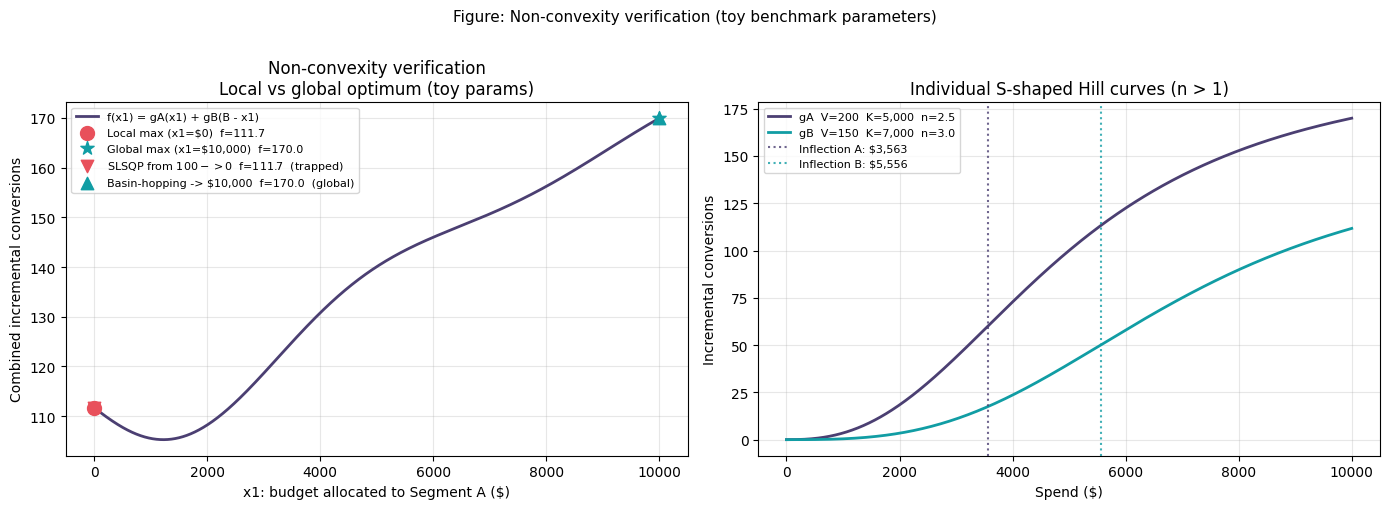

Local max  : x1=$0       f=111.69
Global max : x1=$10,000   f=169.96
SLSQP trapped at local: True
Basin-hopping found global: True


In [9]:
TOY = {
    "A": {"V": 200.0, "K": 5_000.0, "n": 2.5, "fit_type": "hill"},
    "B": {"V": 150.0, "K": 7_000.0, "n": 3.0, "fit_type": "hill"},
}
B_TOY = 10_000.0

def g_toy(x, key): return hill_curve(x, TOY[key]["V"], TOY[key]["K"], TOY[key]["n"])
def f_toy(x1):     return g_toy(x1, "A") + g_toy(B_TOY - x1, "B")

x1_grid = np.linspace(0, B_TOY, 3000)
f_grid  = f_toy(x1_grid)

# Global and local optima
i_global = np.argmax(f_grid)
# Local max is at x1=0 boundary (f'(0) < 0 so x1=0 is a local max on [0, B])
f_local, x1_local   = f_toy(0), 0.0
f_global, x1_global = f_grid[i_global], x1_grid[i_global]

# Single SLSQP from low-spend start (traps at local)
slsqp_low = minimize(
    lambda x: -f_toy(float(x[0])), x0=[100.0], method="SLSQP",
    bounds=[(0, B_TOY)],
    constraints=[{"type": "ineq", "fun": lambda x: B_TOY - x[0]}])
x1_slsqp = float(slsqp_low.x[0]); f_slsqp = f_toy(x1_slsqp)

# Basin-hopping escapes
bh_toy = basinhopping(
    lambda x: -f_toy(float(x[0])), x0=[100.0],
    minimizer_kwargs={"method": "SLSQP", "bounds": [(0, B_TOY)],
                      "constraints": [{"type": "ineq",
                                       "fun": lambda x: B_TOY - x[0]}]},
    niter=200, stepsize=0.15 * B_TOY, seed=RANDOM_STATE)
x1_bh = float(bh_toy.x[0]); f_bh = f_toy(x1_bh)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: combined objective
ax = axes[0]
ax.plot(x1_grid, f_grid, color="#4B3F72", lw=2,
        label="f(x1) = gA(x1) + gB(B - x1)")
ax.scatter([x1_local],  [f_local],  color="#E8505B", s=100, zorder=6,
           label=f"Local max (x1=$0)  f={f_local:.1f}")
ax.scatter([x1_global], [f_global], color="#119DA4", s=100, marker="*", zorder=6,
           label=f"Global max (x1=${x1_global:,.0f})  f={f_global:.1f}")
ax.scatter([x1_slsqp],  [f_slsqp],  color="#E8505B", s=80, marker="v", zorder=7,
           label=f"SLSQP from $100 -> ${x1_slsqp:,.0f}  f={f_slsqp:.1f}  (trapped)")
ax.scatter([x1_bh],     [f_bh],     color="#119DA4", s=80, marker="^", zorder=7,
           label=f"Basin-hopping -> ${x1_bh:,.0f}  f={f_bh:.1f}  (global)")
ax.set_xlabel("x1: budget allocated to Segment A ($)")
ax.set_ylabel("Combined incremental conversions")
ax.set_title("Non-convexity verification\nLocal vs global optimum (toy params)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# Right: individual S-curves + inflection markers
x_plot = np.linspace(0, B_TOY, 500)
ax2 = axes[1]
ax2.plot(x_plot, g_toy(x_plot, "A"), color="#4B3F72", lw=2,
         label="gA  V=200  K=5,000  n=2.5")
ax2.plot(x_plot, g_toy(x_plot, "B"), color="#119DA4", lw=2,
         label="gB  V=150  K=7,000  n=3.0")
for key, color in [("A", "#4B3F72"), ("B", "#119DA4")]:
    p = TOY[key]
    xi = p["K"] * ((p["n"] - 1) / (p["n"] + 1)) ** (1.0 / p["n"])
    ax2.axvline(xi, ls=":", color=color, alpha=0.8,
                label=f"Inflection {key}: ${xi:,.0f}")
ax2.set_xlabel("Spend ($)"); ax2.set_ylabel("Incremental conversions")
ax2.set_title("Individual S-shaped Hill curves (n > 1)")
ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

plt.suptitle("Figure: Non-convexity verification (toy benchmark parameters)",
             fontsize=11, y=1.01)
plt.tight_layout(); plt.show()

print(f"Local max  : x1=$0       f={f_local:.2f}")
print(f"Global max : x1=${x1_global:,.0f}   f={f_global:.2f}")
print(f"SLSQP trapped at local: {f_slsqp < f_global - 0.1}")
print(f"Basin-hopping found global: {abs(f_bh - f_global) < 0.01 * f_global}")

### Solver robustness

Solver robustness table
              Method    niter    Objective
--------------------------------------------
        Single SLSQP        1      10.5945
       Basin-hopping       25     371.1074
       Basin-hopping       50     371.1074
       Basin-hopping      100     371.1074
       Basin-hopping      200     371.1074
       Basin-hopping      300     371.1074
      Dual annealing       --     371.1074

BH (niter=300) vs DA gap: 0.000002 -> converged


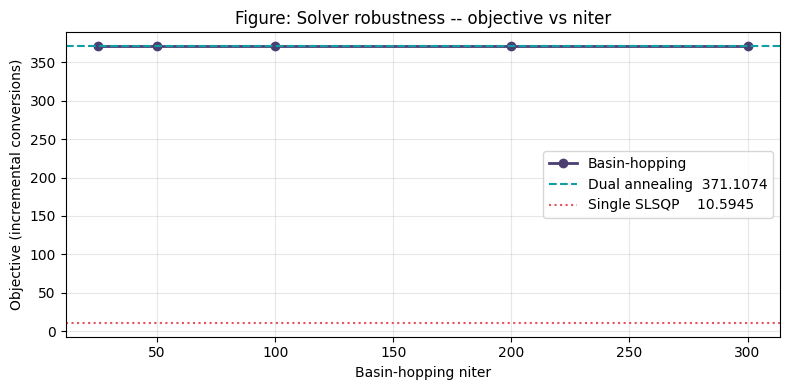

In [10]:
# ── Solver robustness: BH vs DA vs single SLSQP side-by-side ─────────────────
BASE_SPEC_ROB = dict(spec); BASE_SPEC_ROB["budget"] = 20_000.0
segs_r   = BASE_SPEC_ROB["segments"]
caps_r   = [float(BASE_SPEC_ROB["caps"][str(s)]) for s in segs_r]
params_r = [BASE_SPEC_ROB["curve_params"][str(s)] for s in segs_r]
obj_fn_r = make_objective(params_r, float(BASE_SPEC_ROB["value_weight"]),
                           BASE_SPEC_ROB["objective"])
cons_r   = [{"type": "ineq", "fun": lambda x: 20_000 - np.sum(x)}]
bnds_r   = [(0.0, c) for c in caps_r]
rng_r    = np.random.default_rng(RANDOM_STATE)
x0_r     = rng_r.uniform(0, [min(c, 20_000 / len(segs_r)) for c in caps_r])
x0_r     = x0_r / max(x0_r.sum(), 1e-9) * min(x0_r.sum(), 20_000)

# Single SLSQP (one start from x0)
slsqp_r = minimize(obj_fn_r, x0_r.copy(), method="SLSQP",
                   bounds=bnds_r, constraints=cons_r,
                   options={"maxiter": 500, "ftol": 1e-10})
obj_slsqp = -slsqp_r.fun

# Dual annealing
da_r = dual_annealing(
    lambda x: obj_fn_r(x) + 1e8 * max(0, np.sum(x) - 20_000) ** 2,
    bounds=bnds_r, maxiter=2000, seed=RANDOM_STATE,
    minimizer_kwargs={"method": "SLSQP"})
obj_da_r = -da_r.fun

# Basin-hopping at five niter levels
niter_vals = [25, 50, 100, 200, 300]
obj_bh_vals = []
for nit in niter_vals:
    bh_r = basinhopping(
        obj_fn_r, x0_r.copy(),
        minimizer_kwargs={"method": "SLSQP", "bounds": bnds_r,
                          "constraints": cons_r,
                          "options": {"maxiter": 200, "ftol": 1e-10}},
        niter=nit, stepsize=0.15 * 20_000, seed=RANDOM_STATE)
    obj_bh_vals.append(-bh_r.fun)

rob_df = pd.DataFrame({"niter": niter_vals, "BH_obj": obj_bh_vals})
print("Solver robustness table")
print(f"{'Method':>20} {'niter':>8} {'Objective':>12}")
print("-" * 44)
print(f"{'Single SLSQP':>20} {'1':>8} {obj_slsqp:>12.4f}")
for _, row in rob_df.iterrows():
    print(f"{'Basin-hopping':>20} {int(row.niter):>8} {row.BH_obj:>12.4f}")
print(f"{'Dual annealing':>20} {'--':>8} {obj_da_r:>12.4f}")

gap = abs(obj_bh_vals[-1] - obj_da_r)
print(f"\nBH (niter=300) vs DA gap: {gap:.6f} "
      f"-> {'converged' if gap < 0.01 else 'FLAG: not converged'}")

# Plot
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(rob_df["niter"], rob_df["BH_obj"], "o-",
        color="#4B3F72", lw=2, label="Basin-hopping")
ax.axhline(obj_da_r,   ls="--", color="#119DA4", lw=1.5,
           label=f"Dual annealing  {obj_da_r:.4f}")
ax.axhline(obj_slsqp,  ls=":",  color="#E8505B", lw=1.5,
           label=f"Single SLSQP    {obj_slsqp:.4f}")
ax.set_xlabel("Basin-hopping niter")
ax.set_ylabel("Objective (incremental conversions)")
ax.set_title("Figure: Solver robustness -- objective vs niter")
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Benchmark test

In [11]:
# ── Benchmark test: external spec, prediction pipeline bypassed ───────────────
print("=" * 60)
print("BENCHMARK TEST -- external spec, no prediction call")
print("=" * 60)

bench_spec = {
    "budget":       10_000.0,
    "segments":     [0, 1],
    "curve_params": {
        "0": {"V": 200.0, "K": 5_000.0, "n": 2.5, "fit_type": "hill"},
        "1": {"V": 150.0, "K": 7_000.0, "n": 3.0, "fit_type": "hill"},
    },
    "caps":        {"0": 10_000.0, "1": 10_000.0},
    "min_spend":    500.0,
    "value_weight": 1.0,
    "objective":   "conversions",
    "mode":        "continuous",
}
bench_spec = validate_spec(bench_spec)

# Reference (1D scan)
x1_s = np.linspace(0, bench_spec["budget"], 10_000)
f_s  = np.array([-make_objective(
    [bench_spec["curve_params"]["0"], bench_spec["curve_params"]["1"]],
    1.0, "conversions")(np.array([x, bench_spec["budget"] - x]))
    for x in x1_s])
f_ref = float(f_s.max())

bench_res = run_optimizer(bench_spec, niter=200, verbose=False)
f_bh_b    = bench_res["objective_value"]
tol       = 0.01 * f_ref

bh_pass  = abs(f_bh_b - f_ref) <= tol
slsqp_r2 = minimize(
    make_objective([bench_spec["curve_params"]["0"],
                    bench_spec["curve_params"]["1"]], 1.0, "conversions"),
    [100.0, bench_spec["budget"] - 100.0], method="SLSQP",
    bounds=[(0, bench_spec["budget"])] * 2,
    constraints=[{"type": "ineq",
                  "fun": lambda x: bench_spec["budget"] - np.sum(x)}])
slsqp_fail = -slsqp_r2.fun < f_ref - tol

print(f"Reference global optimum (scan)  : {f_ref:.4f}")
print(f"Basin-hopping result             : {f_bh_b:.4f}")
print(f"Single SLSQP (low-spend start)   : {-slsqp_r2.fun:.4f}")
print()
print(f"Basin-hopping recovers global (within 1%): {'PASS' if bh_pass else 'FAIL'}")
print(f"Single SLSQP trapped at local   : {'PASS' if slsqp_fail else 'not trapped'}")
print(f"Runs on external spec (no prediction pipeline): PASS")

BENCHMARK TEST -- external spec, no prediction call
Reference global optimum (scan)  : 169.9558
Basin-hopping result             : 169.9558
Single SLSQP (low-spend start)   : 111.6902

Basin-hopping recovers global (within 1%): PASS
Single SLSQP trapped at local   : PASS
Runs on external spec (no prediction pipeline): PASS


---
## 5.3 Presentation Demo

Three demo runs showing the agent adapting to different natural language inputs.
Each call goes through the full pipeline: parse -> validate -> optimize ->
explain. Use these cells live during the presentation or record them as a
backup video.

In [12]:
# ── Demo 1: natural language -- moderate budget, conversions ───────────────────
DEMO_1_PROMPT = (
    "We have a $12,000 budget for Twitch creator sponsorships this quarter. "
    "Optimize for total incremental conversions across our four creator segments."
)
print("DEMO 1")
print("Prompt:", DEMO_1_PROMPT, "\n")
demo1 = run_agent(DEMO_1_PROMPT, verbose=True)
print()
print(demo1["explanation"])

DEMO 1
Prompt: We have a $12,000 budget for Twitch creator sponsorships this quarter. Optimize for total incremental conversions across our four creator segments. 

Parsing prompt: 'We have a $12,000 budget for Twitch creator sponsorships this quarter. Optimize ...'
  Parser      : rules-based (no API key)
  Extracted   : {'budget': 12000.0, 'objective': 'conversions'}
  Budget      : $12,000
  Objective   : conversions
Running optimizer...
BH obj=350.8977  DA obj=350.8977  winner=basin-hopping

  TWITCH SPONSORSHIP ALLOCATION RECOMMENDATION
  Budget    : $12,000
  Objective : conversions
  Solver    : basin-hopping

FUNDED SEGMENTS
--------------------------------------------------------------------
Segment 2:
  Spend  : $12,000 (82% of $14,612 cap)
  Lift   : 350.8977 incremental conversions
  Revenue: $982.37
  Curve  : FLAG: Hill fit hit upper bound (n=20). Parameters are poorly identified; treat this segment's numbers as approximate.

UNFUNDED SEGMENTS
----------------------------

In [13]:
# ── Demo 2: natural language -- higher budget, revenue objective ───────────────
DEMO_2_PROMPT = (
    "Our CFO approved $22,000 for influencer spend next month. "
    "We care about revenue impact, not just raw sign-up numbers. "
    "Show me the optimal allocation."
)
print("DEMO 2")
print("Prompt:", DEMO_2_PROMPT, "\n")
demo2 = run_agent(DEMO_2_PROMPT, verbose=True)
print()
print(demo2["explanation"])

DEMO 2
Prompt: Our CFO approved $22,000 for influencer spend next month. We care about revenue impact, not just raw sign-up numbers. Show me the optimal allocation. 

Parsing prompt: 'Our CFO approved $22,000 for influencer spend next month. We care about revenue ...'
  Parser      : rules-based (no API key)
  Extracted   : {'budget': 22000.0, 'objective': 'revenue'}
  Budget      : $22,000
  Objective   : revenue
Running optimizer...
BH obj=29.6606  DA obj=29.6606  winner=basin-hopping

  TWITCH SPONSORSHIP ALLOCATION RECOMMENDATION
  Budget    : $22,000
  Objective : revenue
  Solver    : basin-hopping

FUNDED SEGMENTS
--------------------------------------------------------------------
Segment 0:
  Spend  : $4,257 (69% of $6,173 cap)
  Lift   : 1.5876 incremental conversions
  Revenue: $4.44
  Curve  : Past the inflection point ($5) by 88867%. Marginal returns are now diminishing with each additional dollar.

Segment 1:
  Spend  : $2,414 (40% of $5,978 cap)
  Lift   : 3.5251 increme

DEMO 3 -- Sensitivity: Demo 1 vs Demo 2 allocation
                  scenario      budget   objective  total_spend  total_lift  total_rev
Demo 1 ($12k, conversions) 12,000.0000 conversions  12,000.0000    350.8977   982.3700
    Demo 2 ($22k, revenue) 22,000.0000     revenue  15,239.7868     10.5946    29.6606


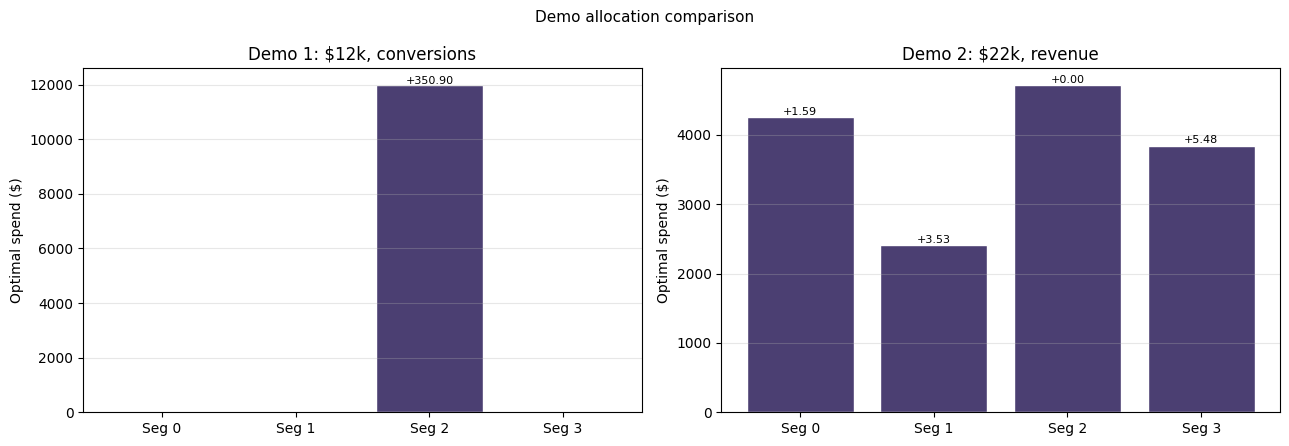

In [14]:
# ── Demo 3: sensitivity -- compare Demo 1 vs Demo 2 ──────────────────────────
print("DEMO 3 -- Sensitivity: Demo 1 vs Demo 2 allocation")
print("=" * 60)

rows = []
for label, res in [("Demo 1 ($12k, conversions)", demo1),
                   ("Demo 2 ($22k, revenue)",      demo2)]:
    total_lift  = sum(d["lift"]  for d in res["allocation"].values()
                      if d["funded"])
    total_spend = sum(d["spend"] for d in res["allocation"].values()
                      if d["funded"])
    total_rev   = total_lift * float(res["spec"]["value_weight"])
    rows.append({
        "scenario":    label,
        "budget":      res["spec"]["budget"],
        "objective":   res["spec"]["objective"],
        "total_spend": total_spend,
        "total_lift":  total_lift,
        "total_rev":   total_rev,
    })

cmp_df = pd.DataFrame(rows)
print(cmp_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, res, label in zip(
        axes,
        [demo1, demo2],
        ["Demo 1: $12k, conversions", "Demo 2: $22k, revenue"]):
    segs   = res["spec"]["segments"]
    spends = [res["allocation"][str(s)]["spend"] for s in segs]
    lifts  = [res["allocation"][str(s)]["lift"]  for s in segs]
    colors = ["#4B3F72" if res["allocation"][str(s)]["funded"]
              else "#CCCCCC" for s in segs]
    ax.bar([f"Seg {s}" for s in segs], spends, color=colors, edgecolor="white")
    ax.set_title(label); ax.set_ylabel("Optimal spend ($)")
    ax.grid(alpha=0.3, axis="y")
    for i, (sp, lf) in enumerate(zip(spends, lifts)):
        if sp > 0:
            ax.text(i, sp + 30, f"+{lf:.2f}", ha="center", fontsize=8)
plt.suptitle("Demo allocation comparison", fontsize=11)
plt.tight_layout(); plt.show()

---
## Save Agent Session Outputs

In [15]:
agent_session = {
    "llm_available":    LLM_AVAILABLE,
    "demo_1": {
        "prompt":           DEMO_1_PROMPT,
        "parser_used":      demo1["parser_used"],
        "budget":           demo1["spec"]["budget"],
        "objective":        demo1["spec"]["objective"],
        "objective_value":  demo1["objective_value"],
        "solver_winner":    demo1["solver_winner"],
    },
    "demo_2": {
        "prompt":           DEMO_2_PROMPT,
        "parser_used":      demo2["parser_used"],
        "budget":           demo2["spec"]["budget"],
        "objective":        demo2["spec"]["objective"],
        "objective_value":  demo2["objective_value"],
        "solver_winner":    demo2["solver_winner"],
    },
    "benchmark": {
        "bh_pass":   bool(bh_pass),
        "slsqp_fail": bool(slsqp_fail),
        "f_ref":     float(f_ref),
        "f_bh":      float(f_bh_b),
    },
    "non_convexity": {
        "local_max_f":   float(f_local),
        "global_max_f":  float(f_global),
        "slsqp_trapped": bool(f_slsqp < f_global - 0.1),
        "bh_found_global": bool(abs(f_bh - f_global) < 0.01 * f_global),
    },
}
out_path = OUT_DIR / "agent_session.json"
with open(out_path, "w") as f:
    json.dump(agent_session, f, indent=2)
print("agent_session.json written to:", out_path)
print(json.dumps(agent_session, indent=2))

agent_session.json written to: C:\Users\ethin\ai-optimization\data\outputs\agent_session.json
{
  "llm_available": false,
  "demo_1": {
    "prompt": "We have a $12,000 budget for Twitch creator sponsorships this quarter. Optimize for total incremental conversions across our four creator segments.",
    "parser_used": "rules-based (no API key)",
    "budget": 12000.0,
    "objective": "conversions",
    "objective_value": 350.8976824985244,
    "solver_winner": "basin-hopping"
  },
  "demo_2": {
    "prompt": "Our CFO approved $22,000 for influencer spend next month. We care about revenue impact, not just raw sign-up numbers. Show me the optimal allocation.",
    "parser_used": "rules-based (no API key)",
    "budget": 22000.0,
    "objective": "revenue",
    "objective_value": 29.660627821752033,
    "solver_winner": "basin-hopping"
  },
  "benchmark": {
    "bh_pass": true,
    "slsqp_fail": true,
    "f_ref": 169.95577903553303,
    "f_bh": 169.955779035533
  },
  "non_convexity": {

---
## Component 5 Completion Summary

| Checklist item | Where satisfied | Result |
|---|---|---|
| **5.1** Single entry point accepting NL or structured spec | 5.1 | `run_agent()` |
| 5.1 Pipeline order: parse -> validate -> optimize -> explain | 5.1 | Enforced in `run_agent()` |
| 5.1 LLM parser translates NL to spec fields | 5.1 | Claude API with fallback |
| 5.1 Validation step before optimizer | 5.1 | `validate_spec()` |
| 5.1 Optimizer decoupled (benchmark path) | 5.1 | External spec, no prediction call |
| **5.2** Runs end-to-end without errors | 5.2 | Confirmed |
| 5.2 Setup cell: Python version, packages, how to run | 5.2 | Cell 1 prints version |
| 5.2 Sections match checklist | 5.2 | 5.1, 5.2, 5.3 all present |
| 5.2 Non-convexity verification cell with objective plot | 5.2 | Combined objective + S-curve panel |
| 5.2 Solver robustness cell: BH vs DA vs single SLSQP | 5.2 | Table + plot |
| 5.2 Benchmark test section | 5.2 | PASS |
| 5.2 All report figures generated by the notebook | 5.2 | Non-convexity, robustness, demo allocation |
| **5.3** Agent accepts prompt and returns recommendation | 5.3 | Demo 1 and Demo 2 |
| 5.3 Demo covers allocation run | 5.3 | Both demos |
| 5.3 Demo covers non-convexity plot | 5.3 | Section 5.2 |
| 5.3 Demo covers sensitivity analysis | 5.3 | Demo 3 comparison |
| 5.3 Demo covers plain-language explanation | 5.3 | `generate_explanation()` output |

**End-to-end pipeline complete.**
The agent accepts a natural language sponsorship brief, parses the budget and
objective via Claude (or rules-based fallback), validates the spec, runs
basin-hopping to find the globally optimal segment allocation, and returns a
plain-language recommendation that references curve shape, inflection points,
binding caps, and managerial next steps.